# Fase 3 — Relações ERA5 × Radar

Objetivo: medir associações descritivas entre os preditores ERA5 (originais e derivados) e o radar. O radar é analisado no domínio `expm1(target)`, chamado aqui de **unidades numéricas da legenda do radar** até confirmação documental da unidade física. Correlação e informação mútua não implicam causalidade.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

def resolve_output(rel):
    candidates = [Path(rel), Path("..") / rel, Path.cwd() / rel, Path.cwd().parent / rel]
    for p in candidates:
        if p.exists():
            return p.resolve()
    return Path(rel).resolve()

OUT = resolve_output("analysis_outputs/03_joint")
print("Usando resultados em:", OUT)


Usando resultados em: /home/vsantos/repositories/rionowcastdf/analysis_outputs/03_joint


In [2]:
def load_parquet(name):
    path = OUT / name
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()

def load_json(name):
    path = OUT / name
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}

summary=load_json("analysis_summary.json")
catalog=load_parquet("predictor_catalog.parquet")
metrics=load_parquet("association_metrics.parquet")
bins=load_parquet("conditional_bins.parquet")
npz=OUT/"relationship_samples.npz"
data=np.load(npz,allow_pickle=False) if npz.exists() else None
if data is not None:
    X=data["predictors"]; radar=data["radar"]; names=[str(v) for v in data["predictor_names"].tolist()]


## 1. Resumo da amostra conjunta

In [3]:
pd.DataFrame([summary])

,phase_version,dataset_dir,dataset_shape,sampled_blocks,retained_pixel_observations,predictor_count,raw_predictor_count,derived_predictor_count,radar_domain,positive_event_rate_in_sample,note
0,phase3-joint-v1,datasets/corrdiff_2011_2024,"[1132464, 12, 32, 32]",64,300000,20,12,8,expm1(stored_target): post-clip numerical rada...,0.01525,Associations are descriptive and represent ove...


## 2. Métricas de associação

In [4]:
cols=["predictor","source","pearson_r","spearman_rho","mutual_information_regression","point_biserial_r_positive","mutual_information_positive_event","n_positive","spearman_rho_positive"]
metrics[cols].sort_values("mutual_information_regression",ascending=False) if not metrics.empty else metrics

,predictor,source,pearson_r,spearman_rho,mutual_information_regression,point_biserial_r_positive,mutual_information_positive_event,n_positive,spearman_rho_positive
0,tcwv,raw,0.131404,0.135475,0.013618,0.134347,0.011411,4575,0.042211
9,r_500,raw,0.153211,0.140847,0.011993,0.159893,0.012310,4575,-0.117777
17,delta_r_500_850,derived,0.123978,0.118482,0.010614,0.129287,0.009908,4575,-0.085801
4,t_850,raw,0.060763,0.051428,0.006041,0.057638,0.005022,4575,0.186015
5,r_850,raw,0.055670,0.058444,0.004443,0.058280,0.003728,4575,-0.054855
15,delta_t_500_850,derived,-0.034196,-0.020705,0.004275,-0.031330,0.003302,4575,-0.161837
10,u_500,raw,0.016759,0.012740,0.003816,0.017939,0.003111,4575,-0.009854
8,t_500,raw,0.051612,0.048772,0.003485,0.050363,0.003439,4575,0.126421
6,u_850,raw,-0.009133,-0.000634,0.003253,-0.013611,0.003405,4575,0.104391
11,v_500,raw,-0.033065,-0.034196,0.002966,-0.034641,0.002130,4575,0.031674


### 2.1 Associação monotônica (Spearman)

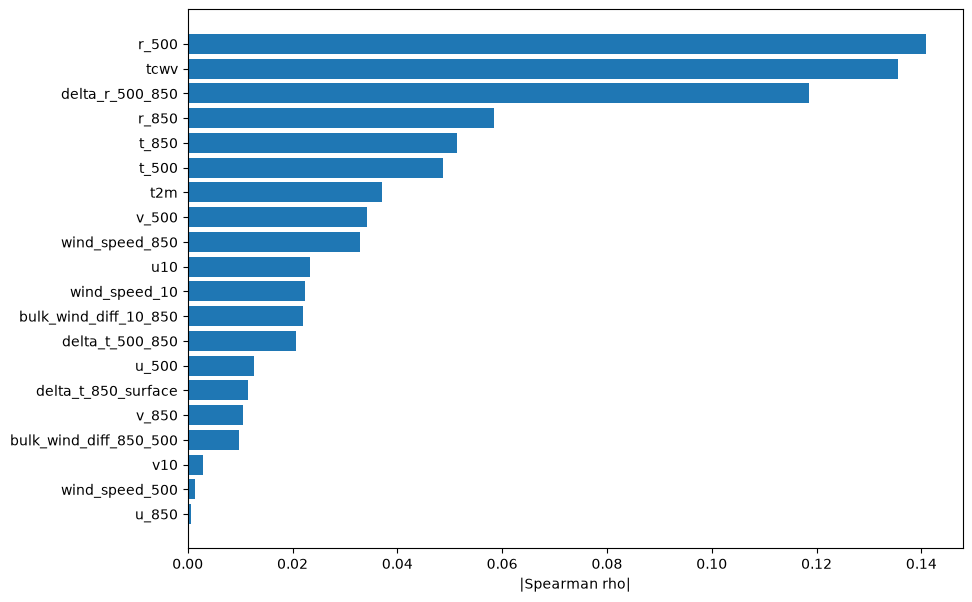

In [11]:
if not metrics.empty:
    d=metrics.copy(); d["abs_spearman"]=d["spearman_rho"].abs(); d=d.sort_values("abs_spearman")
    fig,ax=plt.subplots(figsize=(10,7)); ax.barh(d["predictor"],d["abs_spearman"]); ax.set_xlabel("|Spearman rho|"); plt.show()

### 2.2 Informação mútua com intensidade do radar

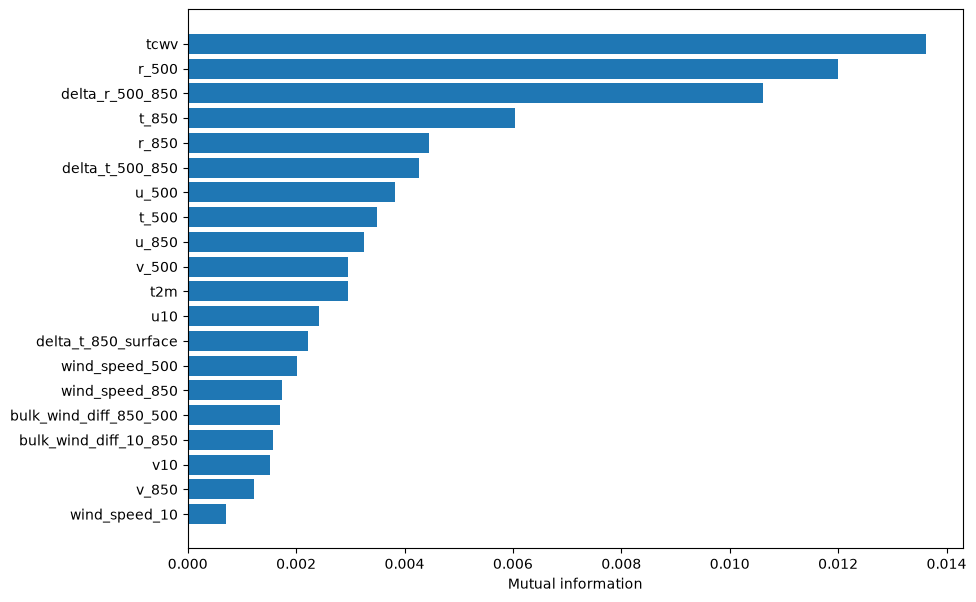

In [12]:
if not metrics.empty:
    d=metrics.sort_values("mutual_information_regression")
    fig,ax=plt.subplots(figsize=(10,7)); ax.barh(d["predictor"],d["mutual_information_regression"]); ax.set_xlabel("Mutual information"); plt.show()

## 3. Probabilidade de evento por bins do preditor

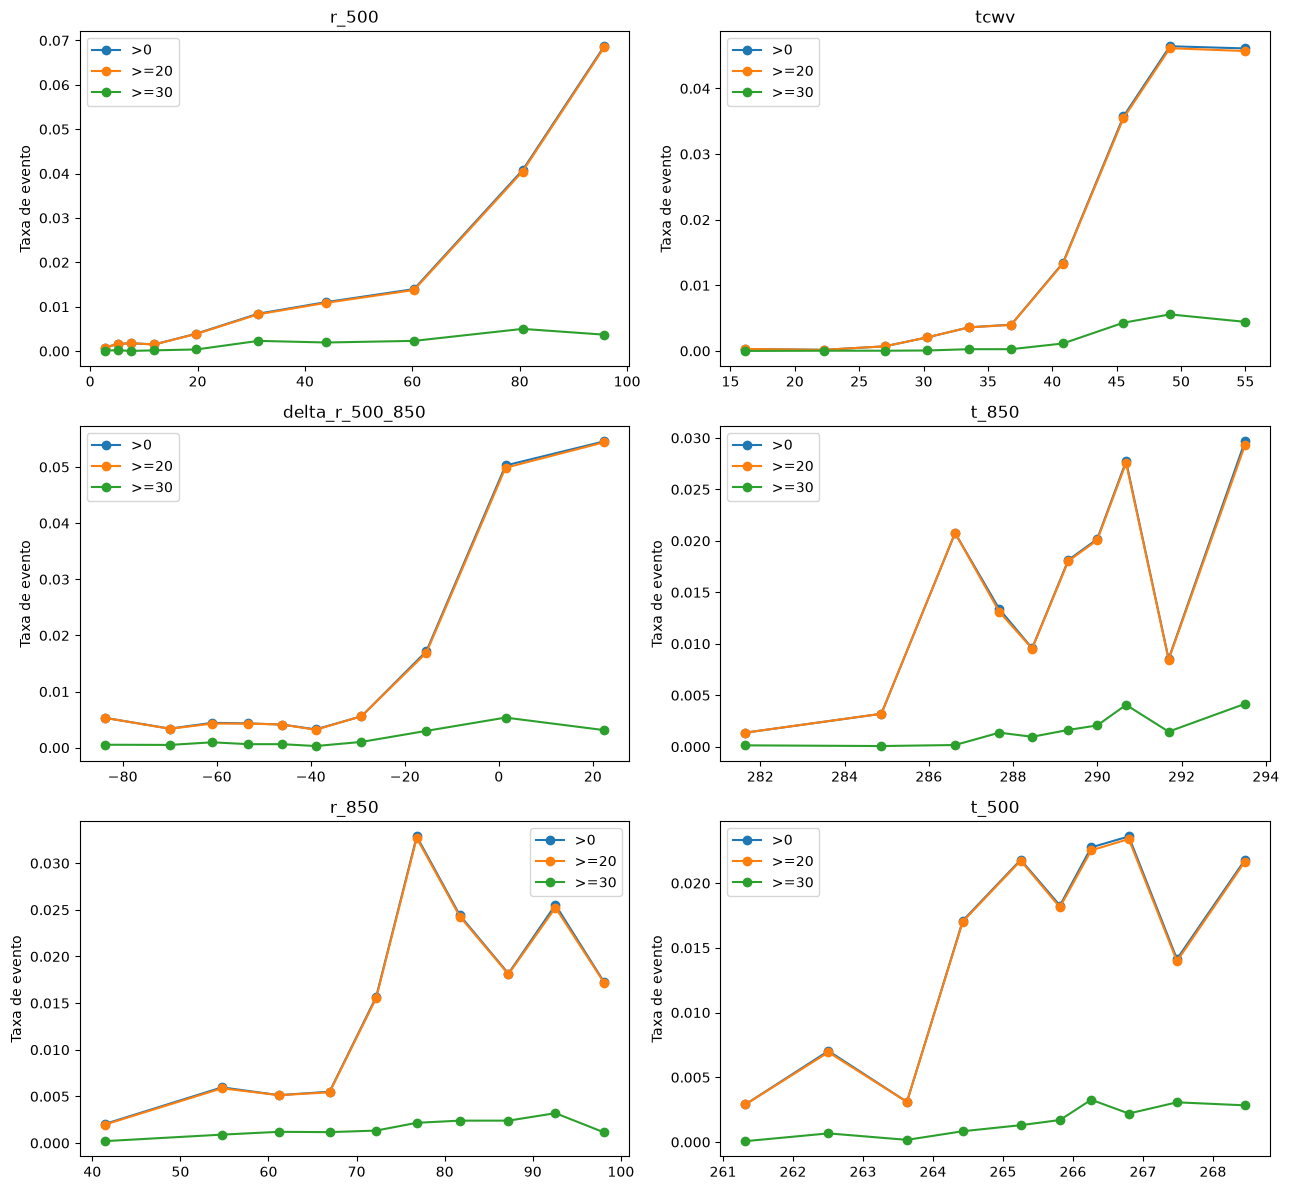

In [13]:
if not metrics.empty and not bins.empty:
    chosen=metrics.sort_values("mutual_information_positive_event",ascending=False)["predictor"].head(6).tolist()
    fig,axes=plt.subplots(3,2,figsize=(13,12)); axes=axes.ravel()
    for ax,name in zip(axes,chosen):
        d=bins[bins.predictor==name].sort_values("x_mean")
        ax.plot(d["x_mean"],d["positive_rate"],marker="o",label=">0")
        ax.plot(d["x_mean"],d["ge20_rate"],marker="o",label=">=20")
        ax.plot(d["x_mean"],d["ge30_rate"],marker="o",label=">=30")
        ax.set_title(name); ax.set_ylabel("Taxa de evento"); ax.legend()
    fig.tight_layout(); plt.show()

## 4. Relações bivariadas — hexbin

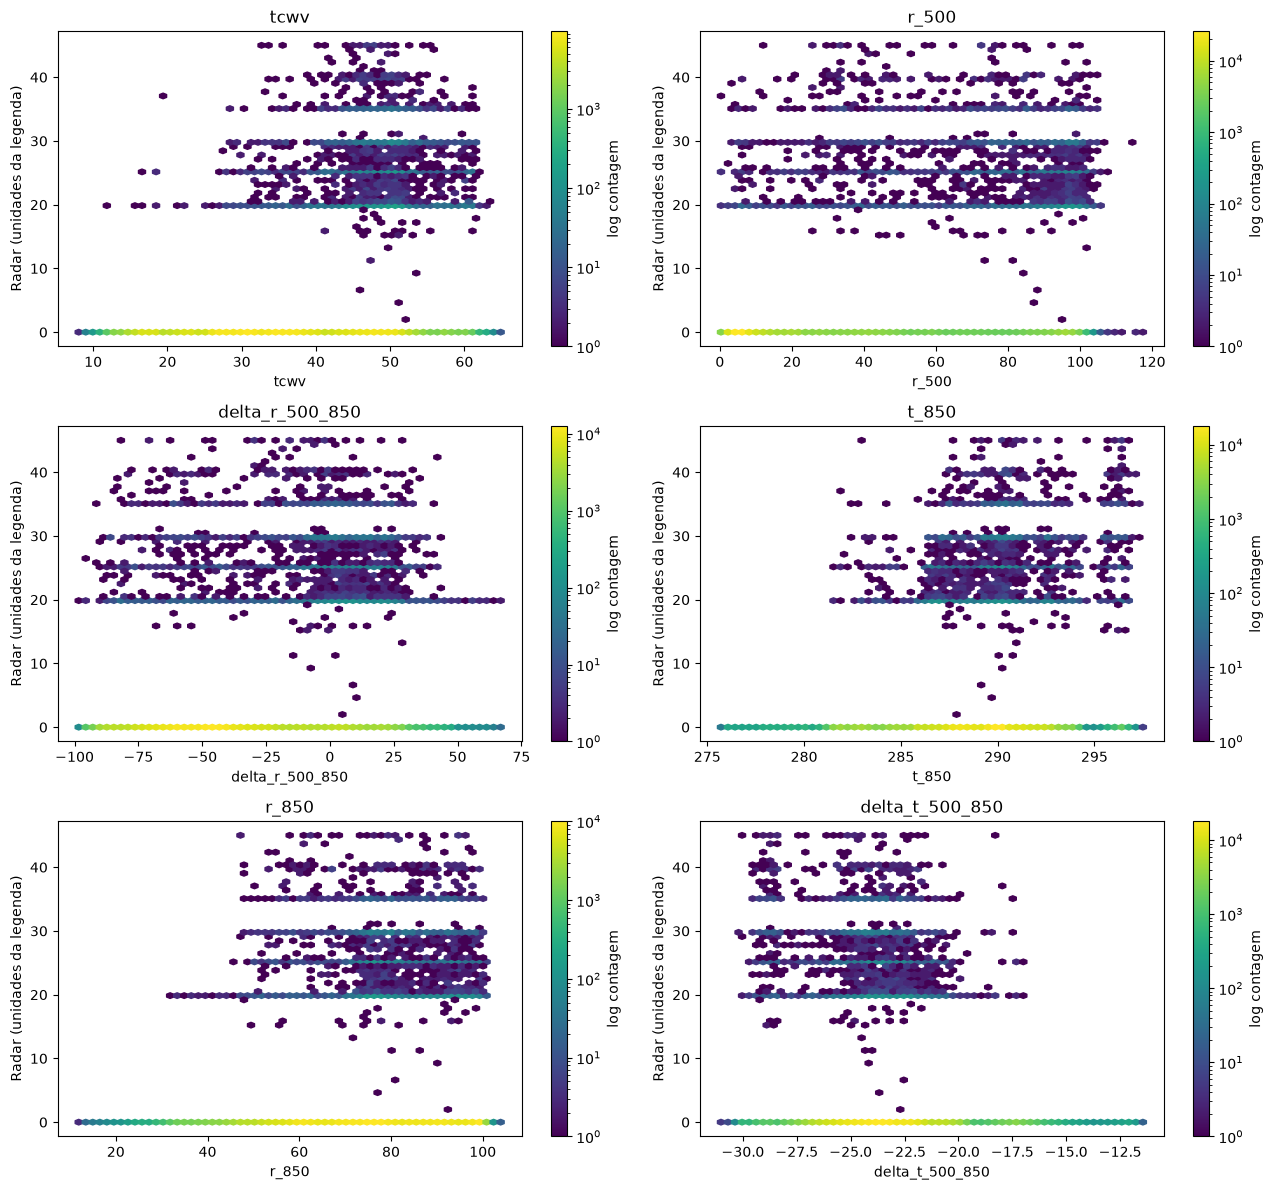

In [14]:
if data is not None and not metrics.empty:
    chosen=metrics.sort_values("mutual_information_regression",ascending=False)["predictor"].head(6).tolist()
    fig,axes=plt.subplots(3,2,figsize=(13,12)); axes=axes.ravel()
    for ax,name in zip(axes,chosen):
        j=names.index(name)
        hb=ax.hexbin(X[:,j],radar,gridsize=60,mincnt=1,bins="log")
        ax.set_xlabel(name); ax.set_ylabel("Radar (unidades da legenda)"); ax.set_title(name)
        fig.colorbar(hb,ax=ax,label="log contagem")
    fig.tight_layout(); plt.show()

## 5. Relação somente durante radar positivo

In [15]:
if not metrics.empty:
    cols=["predictor","n_positive","pearson_r_positive","spearman_rho_positive","mutual_information_regression_positive"]
    display(metrics[cols].sort_values("mutual_information_regression_positive",ascending=False))

,predictor,n_positive,pearson_r_positive,spearman_rho_positive,mutual_information_regression_positive
8,t_500,4575,0.122068,0.126421,0.076931
4,t_850,4575,0.207687,0.186015,0.071685
6,u_850,4575,0.116799,0.104391,0.065042
14,wind_speed_500,4575,-0.031713,0.000809,0.058961
19,bulk_wind_diff_850_500,4575,-0.158162,-0.151210,0.057312
15,delta_t_500_850,4575,-0.180699,-0.161837,0.054978
9,r_500,4575,-0.118077,-0.117777,0.053337
1,t2m,4575,0.240644,0.176675,0.052240
2,u10,4575,0.161044,0.136348,0.049220
16,delta_t_850_surface,4575,-0.108644,-0.081521,0.042275


## 6. Síntese da Fase 3

Use os resultados para selecionar variáveis que merecem investigação física detalhada na Fase 4. Relações fracas globalmente podem ainda ser importantes nos extremos, pois a massa de radar igual a zero domina a distribuição total.

In [16]:
pd.DataFrame([
    {"checagem":"Amostra conjunta disponível","status":"OK" if data is not None else "REVISAR"},
    {"checagem":"20 preditores esperados","status":"OK" if len(catalog)>=20 else "REVISAR"},
    {"checagem":"Métricas calculadas","status":"OK" if len(metrics)>=20 else "REVISAR"},
    {"checagem":"Bins condicionais","status":"OK" if len(bins)>0 else "REVISAR"},
])

,checagem,status
0,Amostra conjunta disponível,OK
1,20 preditores esperados,OK
2,Métricas calculadas,OK
3,Bins condicionais,OK
